# S-Learner Uplift Model

This notebook implements the S-learner (Single-model learner) for uplift modeling using CausalML. The S-learner trains one model that includes treatment as a feature to predict outcomes, then estimates treatment effects by comparing predictions under treatment vs. control conditions. 

### Reproducibility Note

This notebook uses the shared train/test split from `02_feature_matrix.ipynb`. Treatment effects (tau) are estimated and saved for comparison with other uplift methods like T-learner, X-learner, and R-learner.

In [1]:
import sys
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import xgboost as xgb

from causalml.inference.meta import BaseSClassifier
from causalml.metrics import plot_gain, plot_qini, qini_score, auuc_score

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
plt.style.use('seaborn-v0_8-darkgrid')

In [2]:
PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    PROCESSED_DATA_DIR,
    PREDICTIONS_DIR,
    MODEL_RESULTS_DIR,
    FIGURES_DIR,
    RANDOM_STATE,
    PRIMARY_OUTCOME,
    CONTROL_NAME,
)

PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Control group:", CONTROL_NAME)

Project root: /Users/I750170/Rice/Comp653/hillstrom-email-uplift-modeling
Control group: No E-Mail


### Load preprocessed data

In [3]:
X_train = pd.read_csv(PROCESSED_DATA_DIR / "X_train.csv")
X_test = pd.read_csv(PROCESSED_DATA_DIR / "X_test.csv")

y_train = pd.read_csv(PROCESSED_DATA_DIR / "y_train.csv").squeeze()
y_test = pd.read_csv(PROCESSED_DATA_DIR / "y_test.csv").squeeze()

treatment_train = pd.read_csv(PROCESSED_DATA_DIR / "treatment_train.csv").squeeze()
treatment_test = pd.read_csv(PROCESSED_DATA_DIR / "treatment_test.csv").squeeze()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("\nTrain treatment rate:", treatment_train.mean())
print("Test treatment rate:", treatment_test.mean())
print("Train outcome rate:", y_train.mean())
print("Test outcome rate:", y_test.mean())

X_train shape: (48000, 18)
X_test shape: (16000, 18)

Train treatment rate: 0.6670833333333334
Test treatment rate: 0.667125
Train outcome rate: 0.14677083333333332
Test outcome rate: 0.1468125


### Train S-learner with logistic regression

In [4]:
lr_base = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    solver='lbfgs'
)

s_learner_lr = BaseSClassifier(learner=lr_base, control_name=0)

s_learner_lr.fit(
    X=X_train,
    treatment=treatment_train,
    y=y_train
)

print("S-learner (Logistic Regression) trained successfully.")

S-learner (Logistic Regression) trained successfully.


### Predict treatment effects (tau) - Logistic Regression

In [5]:
tau_hat_lr = s_learner_lr.predict(X=X_test, treatment=treatment_test).flatten()

print("Treatment effect predictions (first 10):")
print(tau_hat_lr[:10])
print("\nTreatment effect summary statistics:")
print(pd.Series(tau_hat_lr).describe())

Treatment effect predictions (first 10):
[0.03745485 0.08029355 0.05386858 0.06032043 0.07417848 0.10306601
 0.07641395 0.03861843 0.06174069 0.08534614]

Treatment effect summary statistics:
count    16000.000000
mean         0.059591
std          0.019677
min          0.023767
25%          0.044656
50%          0.057509
75%          0.071838
max          0.129087
dtype: float64


### Train S-learner with XGBoost

In [6]:
xgb_base = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    use_label_encoder=False
)

s_learner_xgb = BaseSClassifier(learner=xgb_base, control_name=0)

s_learner_xgb.fit(
    X=X_train,
    treatment=treatment_train,
    y=y_train
)

print("S-learner (XGBoost) trained successfully.")

S-learner (XGBoost) trained successfully.


### Predict treatment effects (tau) - XGBoost

In [7]:
tau_hat_xgb = s_learner_xgb.predict(X=X_test, treatment=treatment_test).flatten()

print("Treatment effect predictions (first 10):")
print(tau_hat_xgb[:10])
print("\nTreatment effect summary statistics:")
print(pd.Series(tau_hat_xgb).describe())

Treatment effect predictions (first 10):
[0.04592303 0.04559924 0.03657655 0.0188207  0.03052856 0.12531698
 0.04736392 0.02687676 0.07370013 0.0941122 ]

Treatment effect summary statistics:
count    16000.000000
mean         0.058915
std          0.034684
min         -0.197378
25%          0.035202
50%          0.056306
75%          0.079500
max          0.373711
dtype: float64


### Qini curves and AUUC scores

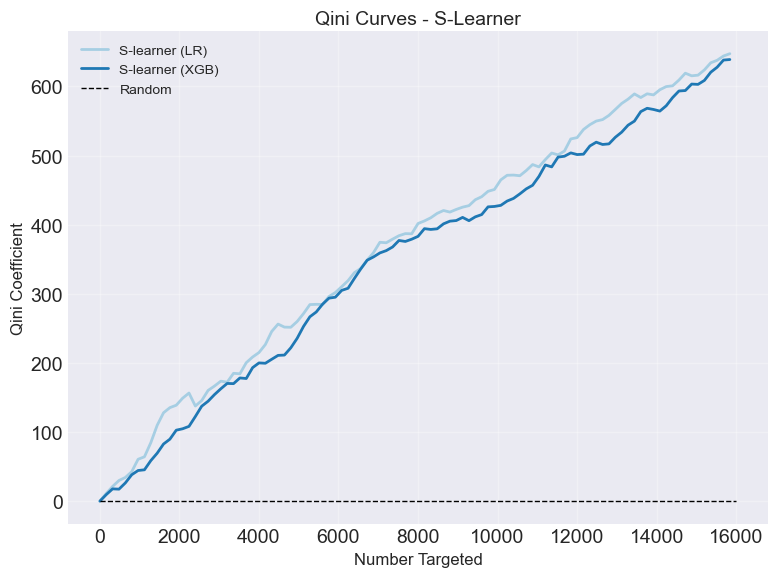

Qini curve saved to: /Users/I750170/Rice/Comp653/hillstrom-email-uplift-modeling/outputs/figures/s_learner_qini.png


In [8]:
def calculate_qini_curve(y, tau, treatment):
    '''Manually calculate Qini curve'''
    df = pd.DataFrame({'y': y, 'tau': tau, 'treatment': treatment})
    df = df.sort_values('tau', ascending=False).reset_index(drop=True)
    
    n_samples = []
    qini_values = []
    
    for i in range(0, len(df), max(1, len(df)//100)):
        subset = df.iloc[:i+1]
        treated = subset[subset['treatment'] == 1]
        control = subset[subset['treatment'] == 0]
        
        if len(control) > 0 and len(treated) > 0:
            qini = treated['y'].sum() - control['y'].sum() * len(treated) / len(control)
        else:
            qini = 0
        
        n_samples.append(i+1)
        qini_values.append(qini)
    
    return n_samples, qini_values

# Calculate Qini curves
n_lr, qini_lr = calculate_qini_curve(y_test.values, tau_hat_lr, treatment_test.values)
n_xgb, qini_xgb = calculate_qini_curve(y_test.values, tau_hat_xgb, treatment_test.values)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(n_lr, qini_lr, label='S-learner (LR)', linewidth=2)
ax.plot(n_xgb, qini_xgb, label='S-learner (XGB)', linewidth=2)
ax.plot([0, len(y_test)], [0, 0], 'k--', label='Random', linewidth=1)
ax.set_xlabel('Number Targeted', fontsize=12)
ax.set_ylabel('Qini Coefficient', fontsize=12)
ax.set_title('Qini Curves - S-Learner', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "s_learner_qini.png", dpi=150)
plt.show()

print("Qini curve saved to:", FIGURES_DIR / "s_learner_qini.png")

In [9]:
def calculate_auuc(y, tau, treatment):
    '''Manually calculate AUUC (Area Under Uplift Curve)'''
    df = pd.DataFrame({'y': y, 'tau': tau, 'treatment': treatment})
    df = df.sort_values('tau', ascending=False).reset_index(drop=True)
    
    n = len(df)
    cumgain = []
    
    for i in range(1, n + 1):
        subset = df.iloc[:i]
        treated = subset[subset['treatment'] == 1]
        control = subset[subset['treatment'] == 0]
        
        if len(control) > 0 and len(treated) > 0:
            gain = treated['y'].sum() - control['y'].sum() * len(treated) / len(control)
        else:
            gain = 0
        cumgain.append(gain)
    
    # Normalize by number of samples and calculate area
    auuc = np.trapz(cumgain) / n
    return auuc

auuc_lr = calculate_auuc(y_test.values, tau_hat_lr, treatment_test.values)
auuc_xgb = calculate_auuc(y_test.values, tau_hat_xgb, treatment_test.values)

print("AUUC Scores:")
print(f"  Logistic Regression: {auuc_lr:.4f}")
print(f"  XGBoost:             {auuc_xgb:.4f}")

AUUC Scores:
  Logistic Regression: 371.0934
  XGBoost:             351.0783


### Cumulative gain charts

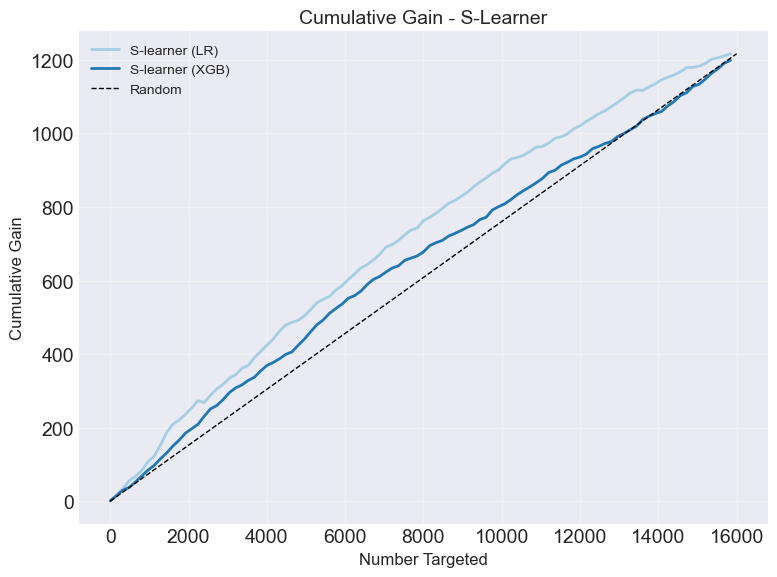

Gain chart saved to: /Users/I750170/Rice/Comp653/hillstrom-email-uplift-modeling/outputs/figures/s_learner_gain.png


In [10]:
def calculate_cumulative_gain(y, tau, treatment):
    '''Manually calculate cumulative gain'''
    df = pd.DataFrame({'y': y, 'tau': tau, 'treatment': treatment})
    df = df.sort_values('tau', ascending=False).reset_index(drop=True)
    
    n_samples = []
    gain_values = []
    
    for i in range(0, len(df), max(1, len(df)//100)):
        subset = df.iloc[:i+1]
        treated = subset[subset['treatment'] == 1]
        control = subset[subset['treatment'] == 0]
        
        gain = treated['y'].sum() - control['y'].sum()
        n_samples.append(i+1)
        gain_values.append(gain)
    
    return n_samples, gain_values

# Calculate cumulative gain
n_lr, gain_lr = calculate_cumulative_gain(y_test.values, tau_hat_lr, treatment_test.values)
n_xgb, gain_xgb = calculate_cumulative_gain(y_test.values, tau_hat_xgb, treatment_test.values)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(n_lr, gain_lr, label='S-learner (LR)', linewidth=2)
ax.plot(n_xgb, gain_xgb, label='S-learner (XGB)', linewidth=2)
ax.plot([0, len(y_test)], [0, gain_lr[-1]], 'k--', label='Random', linewidth=1)
ax.set_xlabel('Number Targeted', fontsize=12)
ax.set_ylabel('Cumulative Gain', fontsize=12)
ax.set_title('Cumulative Gain - S-Learner', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "s_learner_gain.png", dpi=150)
plt.show()

print("Gain chart saved to:", FIGURES_DIR / "s_learner_gain.png")

### Decile lift analysis

In [11]:
def calculate_decile_lift(tau, y, treatment, n_bins=10):
    """
    Calculate lift by decile of predicted treatment effect.
    """
    df = pd.DataFrame({
        'tau': tau,
        'y': y,
        'treatment': treatment
    })
    
    df['decile'] = pd.qcut(df['tau'], q=n_bins, labels=False, duplicates='drop')
    
    decile_stats = []
    for decile in sorted(df['decile'].unique()):
        decile_df = df[df['decile'] == decile]
        
        treated = decile_df[decile_df['treatment'] == 1]
        control = decile_df[decile_df['treatment'] == 0]
        
        treated_rate = treated['y'].mean() if len(treated) > 0 else 0
        control_rate = control['y'].mean() if len(control) > 0 else 0
        
        lift = treated_rate - control_rate
        avg_tau = decile_df['tau'].mean()
        
        decile_stats.append({
            'decile': decile + 1,
            'avg_tau': avg_tau,
            'treated_rate': treated_rate,
            'control_rate': control_rate,
            'lift': lift,
            'n': len(decile_df),
            'n_treated': len(treated),
            'n_control': len(control)
        })
    
    return pd.DataFrame(decile_stats)

decile_lift_lr = calculate_decile_lift(tau_hat_lr, y_test.values, treatment_test.values)
decile_lift_xgb = calculate_decile_lift(tau_hat_xgb, y_test.values, treatment_test.values)

print("Decile Lift - Logistic Regression:")
print(decile_lift_lr[['decile', 'avg_tau', 'lift', 'n']].round(4))

print("\nDecile Lift - XGBoost:")
print(decile_lift_xgb[['decile', 'avg_tau', 'lift', 'n']].round(4))

Decile Lift - Logistic Regression:
   decile  avg_tau    lift     n
0       1   0.0309  0.0446  1600
1       2   0.0387  0.0448  1600
2       3   0.0445  0.0600  1600
3       4   0.0499  0.0501  1601
4       5   0.0549  0.0377  1599
5       6   0.0601  0.0684  1600
6       7   0.0656  0.0763  1600
7       8   0.0721  0.0759  1600
8       9   0.0807  0.0416  1600
9      10   0.0985  0.1232  1600

Decile Lift - XGBoost:
   decile  avg_tau    lift     n
0       1   0.0058  0.0602  1611
1       2   0.0267  0.0655  1589
2       3   0.0351  0.0290  1600
3       4   0.0431  0.0679  1602
4       5   0.0519  0.0292  1598
5       6   0.0611  0.0573  1600
6       7   0.0704  0.0949  1601
7       8   0.0793  0.0491  1605
8       9   0.0909  0.0854  1595
9      10   0.1251  0.0804  1599


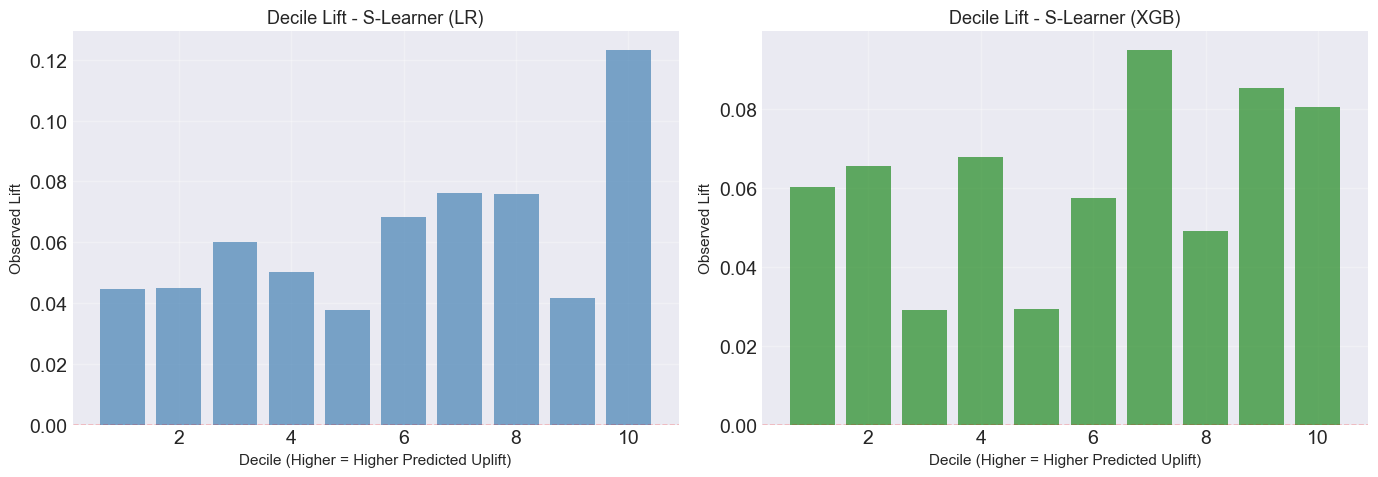

Decile lift chart saved to: /Users/I750170/Rice/Comp653/hillstrom-email-uplift-modeling/outputs/figures/s_learner_decile_lift.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(decile_lift_lr['decile'], decile_lift_lr['lift'], alpha=0.7, color='steelblue')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Decile (Higher = Higher Predicted Uplift)', fontsize=11)
axes[0].set_ylabel('Observed Lift', fontsize=11)
axes[0].set_title('Decile Lift - S-Learner (LR)', fontsize=13)
axes[0].grid(True, alpha=0.3)

axes[1].bar(decile_lift_xgb['decile'], decile_lift_xgb['lift'], alpha=0.7, color='forestgreen')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Decile (Higher = Higher Predicted Uplift)', fontsize=11)
axes[1].set_ylabel('Observed Lift', fontsize=11)
axes[1].set_title('Decile Lift - S-Learner (XGB)', fontsize=13)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "s_learner_decile_lift.png", dpi=150)
plt.show()

print("Decile lift chart saved to:", FIGURES_DIR / "s_learner_decile_lift.png")

### Save predictions

In [13]:
predictions_df = pd.DataFrame({
    'y_true': y_test,
    'treatment': treatment_test,
    'tau_hat_lr': tau_hat_lr,
    'tau_hat_xgb': tau_hat_xgb
})

predictions_path = PREDICTIONS_DIR / "s_learner_predictions.csv"
predictions_df.to_csv(predictions_path, index=False)

print("Predictions saved to:", predictions_path)
print("\nPredictions sample:")
display(predictions_df.head(10))

Predictions saved to: /Users/I750170/Rice/Comp653/hillstrom-email-uplift-modeling/outputs/predictions/s_learner_predictions.csv

Predictions sample:


,y_true,treatment,tau_hat_lr,tau_hat_xgb
0,0,0,0.037455,0.045923
1,0,1,0.080294,0.045599
2,0,1,0.053869,0.036577
3,1,0,0.060320,0.018821
4,1,1,0.074178,0.030529
5,0,1,0.103066,0.125317
6,0,1,0.076414,0.047364
7,1,0,0.038618,0.026877
8,0,0,0.061741,0.073700
9,0,0,0.085346,0.094112


### Save results

In [14]:
results = {
    'logistic_regression': {
        'auuc': float(auuc_lr),
        'mean_tau': float(tau_hat_lr.mean()),
        'std_tau': float(tau_hat_lr.std()),
        'min_tau': float(tau_hat_lr.min()),
        'max_tau': float(tau_hat_lr.max()),
        'decile_lift': decile_lift_lr.to_dict(orient='records')
    },
    'xgboost': {
        'auuc': float(auuc_xgb),
        'mean_tau': float(tau_hat_xgb.mean()),
        'std_tau': float(tau_hat_xgb.std()),
        'min_tau': float(tau_hat_xgb.min()),
        'max_tau': float(tau_hat_xgb.max()),
        'decile_lift': decile_lift_xgb.to_dict(orient='records')
    },
    'metadata': {
        'model_type': 's_learner',
        'outcome': PRIMARY_OUTCOME,
        'test_size': int(len(y_test)),
        'test_treatment_rate': float(treatment_test.mean()),
        'test_outcome_rate': float(y_test.mean())
    }
}

results_path = MODEL_RESULTS_DIR / "s_learner_results.json"
with open(results_path, 'w') as f:
    json.dump(results, f, indent=4)

print("Model results saved to:", results_path)

Model results saved to: /Users/I750170/Rice/Comp653/hillstrom-email-uplift-modeling/outputs/model_results/s_learner_results.json
